In [2]:
from plm import TransformerAmblerModel 
from tokenization import MAX_LEN, vocab_size, encode_and_pad
import tensorflow as tf
from tensorflow.keras.utils import plot_model


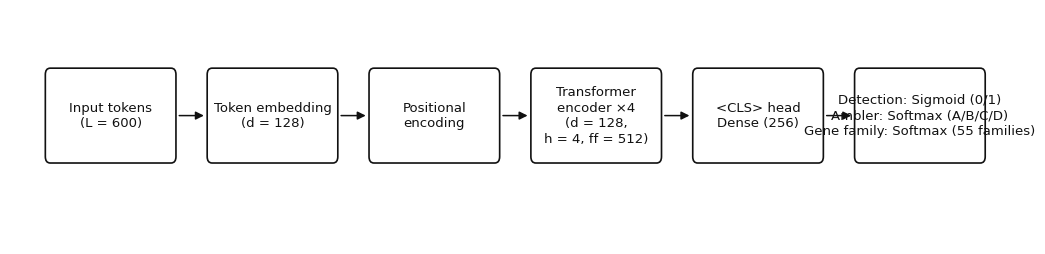

Saved: transformer.pdf, transformer.svg, transformer.png


In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ----------------------------
# Publication-style schematic
# ----------------------------
TITLE = None  # e.g., "Transformer Ambler Classifier" or None
OUT_BASENAME = "transformer"

labels = [
    "Input tokens\n(L = 600)",
    "Token embedding\n(d = 128)",
    "Positional\nencoding",
    "Transformer\nencoder ×4\n(d = 128,\nh = 4, ff = 512)",
    "<CLS> head\nDense (256)",
    "Detection: Sigmoid (0/1)\n"
    "Ambler: Softmax (A/B/C/D)\n"
    "Gene family: Softmax (55 families)",
]

# Figure geometry (tuned for clean spacing)
fig_w, fig_h = 10.5, 2.4
box_w, box_h = 1.55, 0.85
gap = 0.42
left = 0.45
bottom = 0.78

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_axis_off()

if TITLE:
    ax.text(0.5, 0.95, TITLE, transform=ax.transAxes,
            ha="center", va="top", fontsize=12, fontweight="semibold")

# Convert "data coords" for a crisp layout
# We draw in axis fraction coordinates for consistent rendering across backends.
ax.set_xlim(0, left + len(labels) * (box_w + gap))
ax.set_ylim(0, 2.2)

y = bottom

# Subtle, print-friendly styling
box_fc = "#FFFFFF"
box_ec = "#111111"
arrow_c = "#111111"
text_c = "#111111"

xs = []
for i, lab in enumerate(labels):
    x = left + i * (box_w + gap)
    xs.append(x)

    rect = FancyBboxPatch(
        (x, y),
        box_w, box_h,
        boxstyle="round,pad=0.02,rounding_size=0.06",
        linewidth=1.2,
        edgecolor=box_ec,
        facecolor=box_fc
    )
    ax.add_patch(rect)

    ax.text(
        x + box_w / 2,
        y + box_h / 2,
        lab,
        ha="center",
        va="center",
        fontsize=9.5,
        color=text_c,
        linespacing=1.25,
    )

# Arrows (consistent, slim, centered)
for i in range(len(labels) - 1):
    x0 = xs[i] + box_w
    x1 = xs[i + 1]
    ymid = y + box_h / 2

    arrow = FancyArrowPatch(
        (x0 + 0.06, ymid),
        (x1 - 0.06, ymid),
        arrowstyle="-|>",
        mutation_scale=12,
        linewidth=1.1,
        color=arrow_c,
        shrinkA=0,
        shrinkB=0,
    )
    ax.add_patch(arrow)

# Tight, vector-friendly export
fig.tight_layout(pad=0.2)
fig.savefig(f"{OUT_BASENAME}.pdf")   # vector (best for papers)
fig.savefig(f"{OUT_BASENAME}.svg")   # vector (edit in Illustrator/Inkscape)
fig.savefig(f"{OUT_BASENAME}.png", dpi=600)  # high-res raster fallback
plt.show()

print(f"Saved: {OUT_BASENAME}.pdf, {OUT_BASENAME}.svg, {OUT_BASENAME}.png")


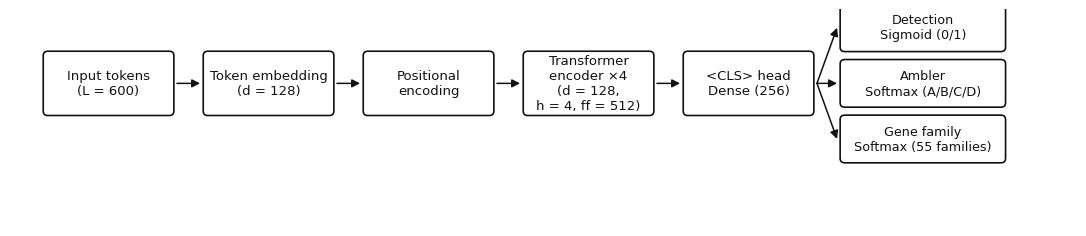

Saved: transformer.pdf, transformer.svg, transformer.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

TITLE = None
OUT_BASENAME = "transformer"

# ----------------------------
# Labels
# ----------------------------
core_labels = [
    "Input tokens\n(L = 600)",
    "Token embedding\n(d = 128)",
    "Positional\nencoding",
    "Transformer\nencoder ×4\n(d = 128,\nh = 4, ff = 512)",
    "<CLS> head\nDense (256)",
]

head_labels = [
    "Detection\nSigmoid (0/1)",
    "Ambler\nSoftmax (A/B/C/D)",
    "Gene family\nSoftmax (55 families)",
]

# ----------------------------
# Geometry (tuned)
# ----------------------------
fig_w, fig_h = 11.5, 3

box_w, box_h = 1.65, 0.85
gap = 0.42
left = 0.45
y_core = 1.55

stack_w, stack_h = 2.10, 0.62
stack_gap = 0.15
stack_x_offset = 0.38  # pushes stack slightly right of CLS box edge

# ----------------------------
# Figure
# ----------------------------
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_axis_off()

if TITLE:
    ax.text(0.5, 0.98, TITLE, transform=ax.transAxes,
            ha="center", va="top", fontsize=12, fontweight="semibold")

# Style
box_fc = "#FFFFFF"
box_ec = "#111111"
arrow_c = "#111111"
text_c = "#111111"

# Layout extents
n_core = len(core_labels)
xmax = left + n_core * (box_w + gap) + stack_w + 0.9
ax.set_xlim(0, xmax)
ax.set_ylim(0, 3.0)

def add_box(x, y, w, h, text, fontsize=9.5, lw=1.2):
    rect = FancyBboxPatch(
        (x, y),
        w, h,
        boxstyle="round,pad=0.02,rounding_size=0.06",
        linewidth=lw,
        edgecolor=box_ec,
        facecolor=box_fc
    )
    ax.add_patch(rect)
    ax.text(
        x + w/2, y + h/2, text,
        ha="center", va="center",
        fontsize=fontsize,
        color=text_c,
        linespacing=1.20
    )
    return rect

def add_arrow(x0, y0, x1, y1):
    arrow = FancyArrowPatch(
        (x0, y0), (x1, y1),
        arrowstyle="-|>",
        mutation_scale=12,
        linewidth=1.1,
        color=arrow_c,
        shrinkA=0,
        shrinkB=0,
    )
    ax.add_patch(arrow)

# ----------------------------
# Core pipeline boxes
# ----------------------------
xs = []
for i, lab in enumerate(core_labels):
    x = left + i * (box_w + gap)
    xs.append(x)
    add_box(x, y_core, box_w, box_h, lab)

# Core arrows
for i in range(len(core_labels) - 1):
    x0 = xs[i] + box_w
    x1 = xs[i + 1]
    ymid = y_core + box_h / 2
    add_arrow(x0 + 0.06, ymid, x1 - 0.06, ymid)

# ----------------------------
# Output head stack (3 boxes) + 3 arrows from CLS head
# ----------------------------
x_cls = xs[-1]
y_cls_mid = y_core + box_h / 2

stack_x = x_cls + box_w + stack_x_offset
stack_total_h = 3 * stack_h + 2 * stack_gap

TOP_MARGIN = 0.25  # increase this to add more whitespace at the top
stack_y_top = y_cls_mid + stack_total_h / 2 - stack_h - TOP_MARGIN


stack_boxes = []
for i, lab in enumerate(head_labels):
    y = stack_y_top - i * (stack_h + stack_gap)
    r = add_box(stack_x, y, stack_w, stack_h, lab, fontsize=9.2)
    stack_boxes.append(r)

# Three arrows from CLS head box to each head
x_from = x_cls + box_w
for r in stack_boxes:
    # Arrow to left-mid of each stacked box
    x_to = r.get_x()
    y_to = r.get_y() + r.get_height() / 2
    add_arrow(x_from + 0.06, y_cls_mid, x_to - 0.06, y_to)

# ----------------------------
# Save
# ----------------------------
fig.tight_layout(pad=3)
fig.savefig(f"{OUT_BASENAME}.pdf")
fig.savefig(f"{OUT_BASENAME}.svg")
fig.savefig(f"{OUT_BASENAME}.png", dpi=600)
plt.show()

print(f"Saved: {OUT_BASENAME}.pdf, {OUT_BASENAME}.svg, {OUT_BASENAME}.png")
